In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn.objects as so
from seaborn import axes_style

In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
theme_dict = {**axes_style('whitegrid'), 'context': 'notebook', 'palette': 'muted'}
so.Plot.config.theme.update(theme_dict)

In [4]:
data_dir = Path('../../data')
results_dir = Path('../../results')

ts = pd.read_csv(data_dir / 'imdb_ts.csv', index_col=0)
additional_features = pd.read_csv(results_dir / 'ts_additional_feats.csv', index_col=0)

In [5]:
ts.isna().values.any()

np.False_

In [6]:
ts = pd.merge(additional_features, ts, left_index=True, right_index=True)

No missing values in the entire dataframe.

In [7]:
ts['totalGrossIncome'] = ts.iloc[:, 6:-3].sum(axis=1)

We reorder the columns to make easier to inspect the dataframe.

In [8]:
cols = list(ts.columns[:6]) + list(ts.columns[-4:])
ts = ts[cols + [col for col in ts.columns if col not in cols]]

## Train test split

It would be nice if this time we could avoid data leakage.

In [9]:
train, test = train_test_split(ts, shuffle=True, random_state=42)

In [10]:
print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (850, 110)
Test set: (284, 110)


## Data exploration

In [11]:
train.head()

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,Missing,2023,111,68822,"US,RU",True,7.1,"['Drama', 'Mystery', 'Thriller']",High,64003902.0,...,180769.0,125336.0,86468.0,34939.0,41054.0,46551.0,39476.0,32835.0,24195.0,15942.0
tt3766354,The Equalizer 2,2018,121,218592,US,True,6.7,"['Action', 'Crime', 'Thriller']",Medium High,197504987.0,...,561537.0,560423.0,476123.0,386849.0,262398.0,145408.0,127290.0,108184.0,97706.0,85139.0
tt6791096,I Feel Pretty,2018,110,59184,"CN,US",True,5.7,"['Comedy', 'Romance']",Medium,94719880.0,...,105024.0,79110.0,57297.0,37058.0,44995.0,52408.0,45573.0,37329.0,32947.0,28392.0
tt1821549,Nebraska,2013,115,126617,US,True,7.7,['Drama'],High,13195238.0,...,251542.0,207354.0,177589.0,146206.0,169318.0,200356.0,211349.0,220125.0,163567.0,106825.0
tt7144666,The Black Phone,2021,103,230716,US,True,6.9,"['Horror', 'Mystery', 'Thriller']",Medium High,171072300.0,...,523746.0,448800.0,317950.0,218585.0,223136.0,227210.0,209270.0,187610.0,161602.0,141360.0


In [12]:
train.iloc[:, :9].info()

<class 'pandas.core.frame.DataFrame'>
Index: 850 entries, tt10855768 to tt9620292
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                850 non-null    object 
 1   startYear            850 non-null    int64  
 2   runtimeMinutes       850 non-null    int64  
 3   numVotes             850 non-null    int64  
 4   countryOfOrigin      850 non-null    object 
 5   awardsOrNominations  846 non-null    object 
 6   rating               850 non-null    float64
 7   genre                850 non-null    object 
 8   rating_category      850 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 66.4+ KB


In [13]:
from ast import literal_eval

In [14]:
train['genre'] = train['genre'].apply(literal_eval)
train['countryOfOrigin'] = train['countryOfOrigin'].str.split(',')

### Distribution of numeric features

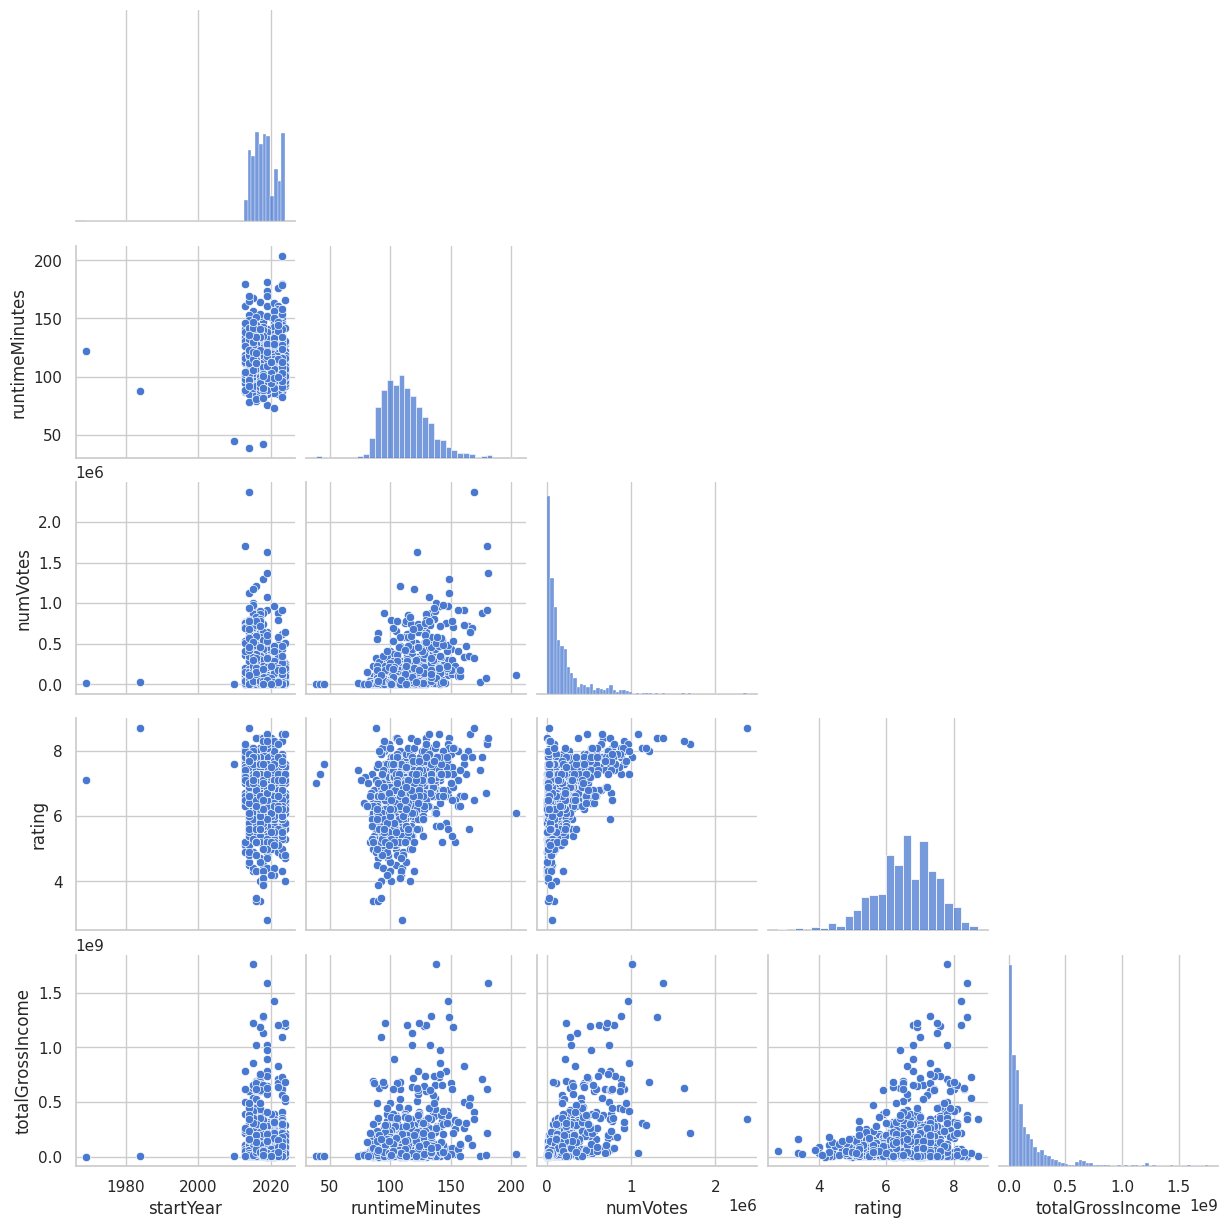

In [15]:
sns.pairplot(train, vars=['startYear', 'runtimeMinutes', 'numVotes', 'rating', 'totalGrossIncome'], corner=True)

All of the records have normal runtimes for movies, except for 3 documentaries with runtime $\leq$ 45 minutes

In [16]:
train[train['runtimeMinutes'] < 50]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt3231010,Island of Lemurs: Madagascar,2014,39,1050,"[CA, US, MG]",True,7.0,"[Documentary, Short, Adventure]",Medium High,4010707.0,...,43594.0,35506.0,34024.0,32765.0,28718.0,26583.0,29048.0,31629.0,38254.0,44658.0
tt7860270,Pandas,2018,42,776,[US],True,7.3,"[Documentary, Short]",High,2997945.0,...,44159.0,38325.0,38062.0,37858.0,30437.0,22984.0,21404.0,20198.0,22996.0,25430.0
tt1433813,Hubble,2010,45,4615,"[US, CA]",True,7.6,[Documentary],High,9792807.0,...,120846.0,101100.0,78704.0,56433.0,60007.0,63236.0,67514.0,71599.0,77404.0,81896.0


All records except 2 are fairly recent (released in 2010 or later).

Ignoring outliers, the distribution of movies for release date is uniform, except for the already observed dip in 2020.

<Axes: xlabel='startYear'>

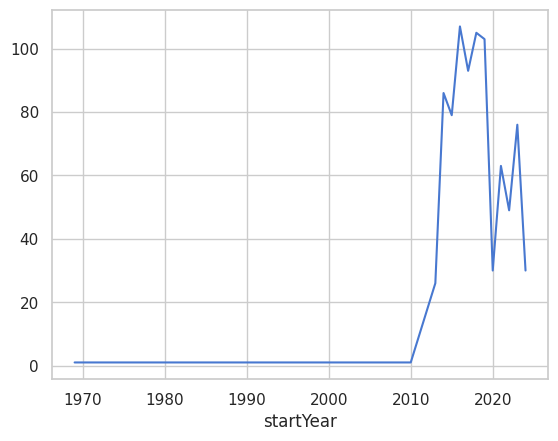

In [17]:
train.groupby('startYear')['title'].count().plot()

In [18]:
train[train['startYear'] < 2010]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0088178,Stop Making Sense,1984,88,22937,[US],True,8.7,"[Documentary, Music]",High,8622103.0,...,16273.0,14396.0,10518.0,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0
tt0064816,The Swimming Pool,1969,122,15308,"[FR, IT]",False,7.1,"[Crime, Drama, Romance]",High,139777.0,...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0


Distribution of `numVotes` has a right skew, so does `totalGrossIncome`. It makes perfect sense for the distribution of both features to follow a power law.

In [19]:
train.numVotes.describe()

count    8.500000e+02
mean     1.803665e+05
std      2.410378e+05
min      8.500000e+01
25%      3.428200e+04
50%      9.672950e+04
75%      2.190652e+05
max      2.374947e+06
Name: numVotes, dtype: float64

In [20]:
train.sort_values('numVotes', ascending=False).head()

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,90,91,92,93,94,95,96,97,98,99
id,,,,,,,,,,,,,,,,,,,,,
tt0816692,Interstellar,2014,169,2374947,"[US, GB, CA]",True,8.7,"[Adventure, Drama, Sci-Fi]",High,3.487517e+08,...,593663.0,720577.0,896340.0,1070807.0,991763.0,910905.0,786939.0,660732.0,710859.0,763250.0
tt0993846,The Wolf of Wall Street,2013,180,1703709,[US],True,8.2,"[Biography, Comedy, Crime]",High,2.150253e+08,...,516835.0,636727.0,921125.0,1212685.0,959817.0,733352.0,485552.0,215064.0,230368.0,244186.0
tt7286456,Joker,2019,122,1625673,"[US, CA, AU]",True,8.3,"[Crime, Drama, Thriller]",High,6.322560e+08,...,1908740.0,1371816.0,943600.0,426673.0,513630.0,609986.0,533751.0,443301.0,383414.0,328871.0
tt4154796,Avengers: Endgame,2019,181,1374452,[US],NaN,8.4,"[Action, Adventure, Sci-Fi]",High,1.589580e+09,...,1829579.0,1583859.0,1057981.0,598373.0,700030.0,790276.0,686876.0,601476.0,570854.0,547331.0
tt4154756,Avengers: Infinity War,2018,149,1302471,"[US, NO]",True,8.4,"[Action, Adventure, Sci-Fi]",High,1.276892e+09,...,2644515.0,2403780.0,1719860.0,922933.0,1054992.0,1182541.0,1051254.0,895177.0,820151.0,766901.0


<Axes: >

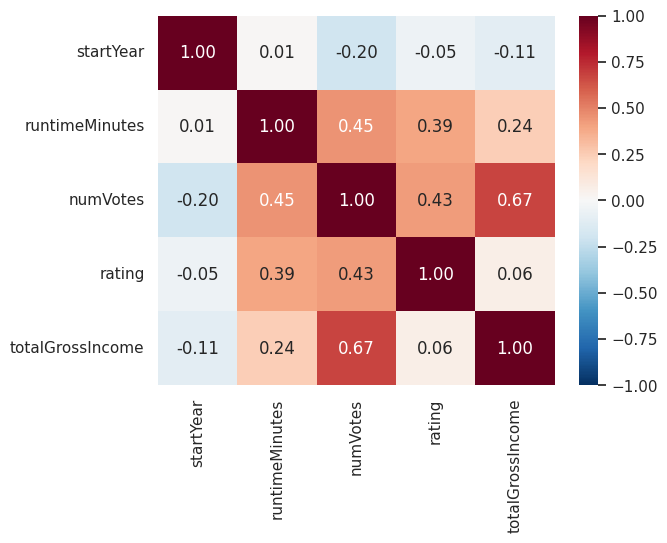

In [21]:
sns.heatmap(train[['startYear', 'runtimeMinutes', 'numVotes', 'rating', 'totalGrossIncome']].corr(method='spearman'),
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f')

Positive correlation of numVotes with rating is something we didn't observe in the other dataset.
Weak negative correlation between rating and numVotes observed in the other dataset, which is somewhat unexpected, may be due to the fact that movies have, on average, lower ratings than TV Episodes, which, in turn, have fewer votes than Movies. Since this other dataset is limited to movies, we do not observe this relationship.

There's a moderate to strong positive correlation between total gross income and number of votes.
Perhaps surprisingly, total gross income is only weakly correlated with rating.

### Distribution of categorical features

#### Categorical rating

In [22]:
train['rating_category'] = pd.Categorical(train['rating_category'],
               categories=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
               ordered=True)

<Axes: xlabel='rating_category', ylabel='count'>

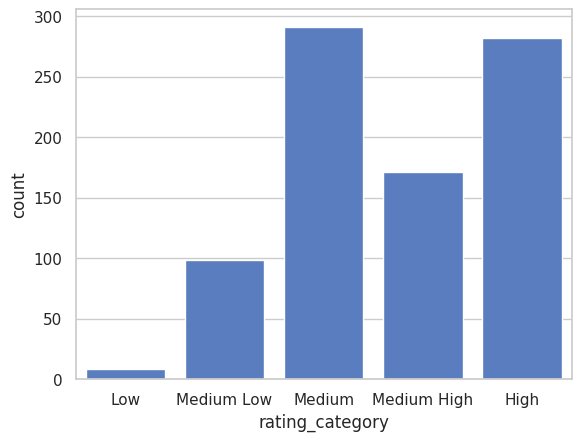

In [23]:
sns.countplot(train, x='rating_category')

#### Awards and Nominations

Almost all titles received awards or nominations.

<Axes: xlabel='awardsOrNominations'>

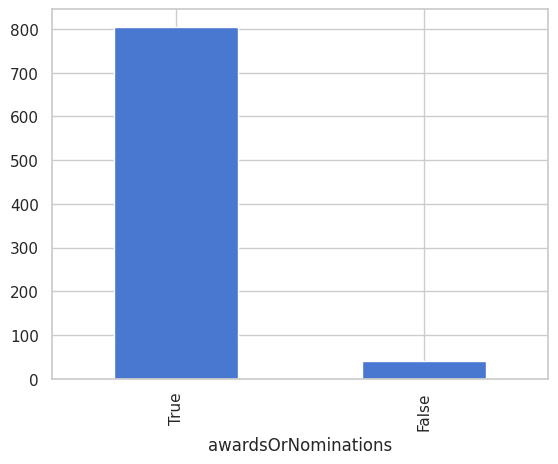

In [24]:
train['awardsOrNominations'].value_counts().plot.bar()

#### Country of Origin

<Axes: ylabel='countryOfOrigin'>

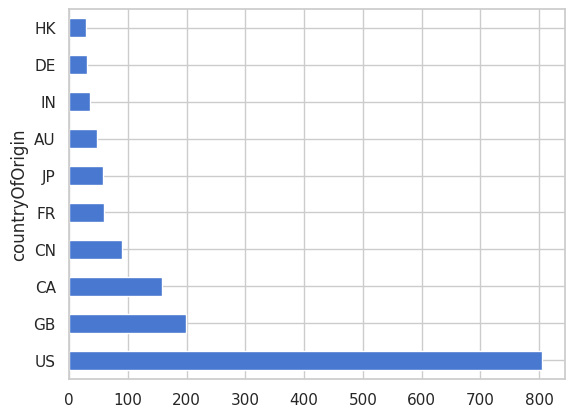

In [25]:
country_train = train.explode('countryOfOrigin')
country_counts = country_train['countryOfOrigin'].value_counts()
country_counts.to_frame().sort_values('count', ascending=False).head(10).plot.barh(legend=False)

In [26]:
train['foreign'] = train['countryOfOrigin'].apply(lambda x: 'US' not in x)
train['foreign'].value_counts()

foreign
False    804
True      46
Name: count, dtype: int64

Only a small proportion of these movies was not produced in the United States.

#### Genre

<Axes: ylabel='genre'>

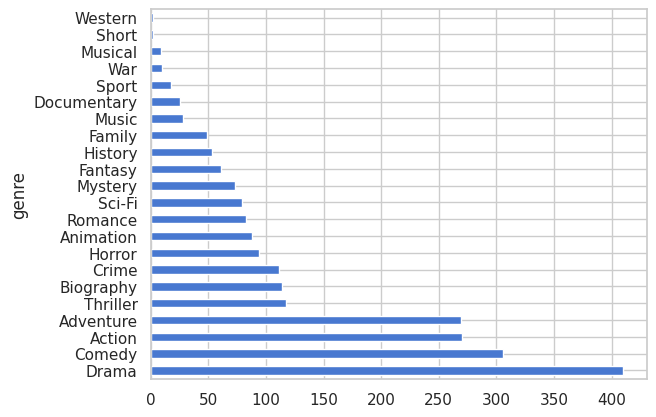

In [27]:
genres_train = train.explode('genre')
genres_train['genre'].value_counts().plot.barh()

In [28]:
genres_train[genres_train['genre'] == 'Action'].head()

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,91,92,93,94,95,96,97,98,99,foreign
id,,,,,,,,,,,,,,,,,,,,,
tt3766354,The Equalizer 2,2018,121,218592,[US],True,6.7,Action,Medium High,1.975050e+08,...,560423.0,476123.0,386849.0,262398.0,145408.0,127290.0,108184.0,97706.0,85139.0,False
tt1840309,Divergent,2014,139,508145,[US],True,6.6,Action,Medium High,2.784951e+08,...,558830.0,406881.0,145690.0,166936.0,194272.0,183414.0,171202.0,157052.0,143746.0,False
tt3076658,Creed,2015,133,324138,[US],True,7.6,Action,High,2.113196e+08,...,448454.0,589180.0,704835.0,536743.0,360971.0,237178.0,125339.0,143782.0,157802.0,False
tt10676048,The Marvels,2023,105,153166,[US],True,5.5,Action,Medium Low,1.588031e+08,...,11286.0,9868.0,8239.0,8665.0,8948.0,8476.0,8087.0,8507.0,8895.0,False
tt4154756,Avengers: Infinity War,2018,149,1302471,"[US, NO]",True,8.4,Action,High,1.276892e+09,...,2403780.0,1719860.0,922933.0,1054992.0,1182541.0,1051254.0,895177.0,820151.0,766901.0,False


Text(0.5, 0, 'Genre=Action')

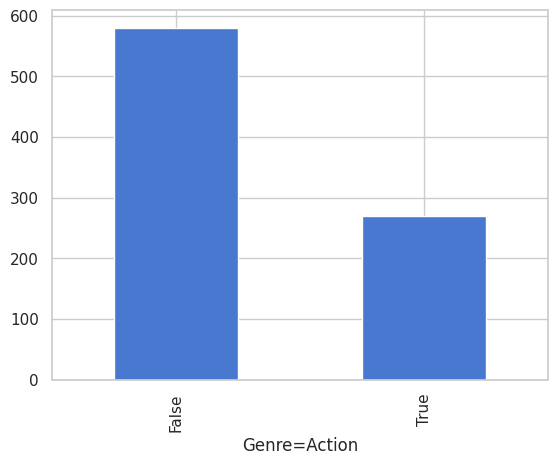

In [29]:
train['genre'].apply(lambda x: 'Action' in x).value_counts().plot.bar()
plt.xlabel('Genre=Action')

Action movies vs non action movies is probably a good candidate for classification and/or something to check against time series clustering in addition to the rating category.

## Clustering on tabular data

We perform hierarchical clustering using all numeric features except for total gross income. Since we may want to check this clustering againts clustering performed on the time series, we don't think it is appropriate to include information that comes from the time series in the clustering.

In [30]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import numpy as np

In [31]:
def get_linkage_matrix(model):
    # Create linkage matrix

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [32]:
clust = AgglomerativeClustering(
    distance_threshold=0,
    compute_distances=True,
    n_clusters=None,
    linkage='ward'
)

estimator = make_pipeline(
    RobustScaler(),
    clust
)
estimator

,steps,"[('robustscaler', ...), ('agglomerativeclustering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,n_clusters,None
,metric,'euclidean'


Preprocess the dataset (log transform `numVotes` that has a right skew).

/tmp/ipykernel_28468/1972595450.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_X['numVotes'] = np.log(train_X['numVotes'])


<Axes: ylabel='Frequency'>

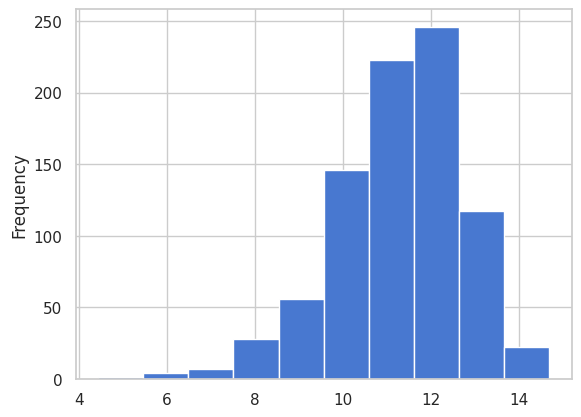

In [33]:
train_X = train[['startYear', 'runtimeMinutes', 'numVotes', 'rating']]
train_X['numVotes'] = np.log(train_X['numVotes'])
train_X['numVotes'].plot.hist()

In [34]:
estimator.fit(train_X)

,steps,"[('robustscaler', ...), ('agglomerativeclustering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,n_clusters,None
,metric,'euclidean'


([], [])

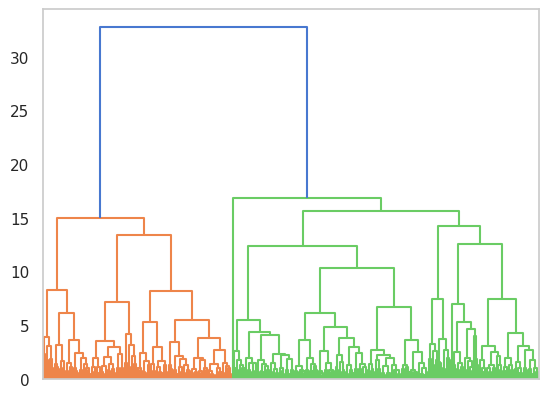

In [35]:
plot_dendrogram(estimator[-1])
plt.grid(None)
plt.xticks([], [])

In [36]:
linkage_matrix = get_linkage_matrix(estimator[-1])
labels = fcluster(linkage_matrix, criterion='distance', t=19)
np.unique(labels, return_counts=True)

(array([1, 2], dtype=int32), array([325, 525]))

In [37]:
print("Silhouette score:", silhouette_score(train_X, labels))

Silhouette score: 0.2998498741258157


In [38]:
train['cluster'] = pd.Categorical(labels)

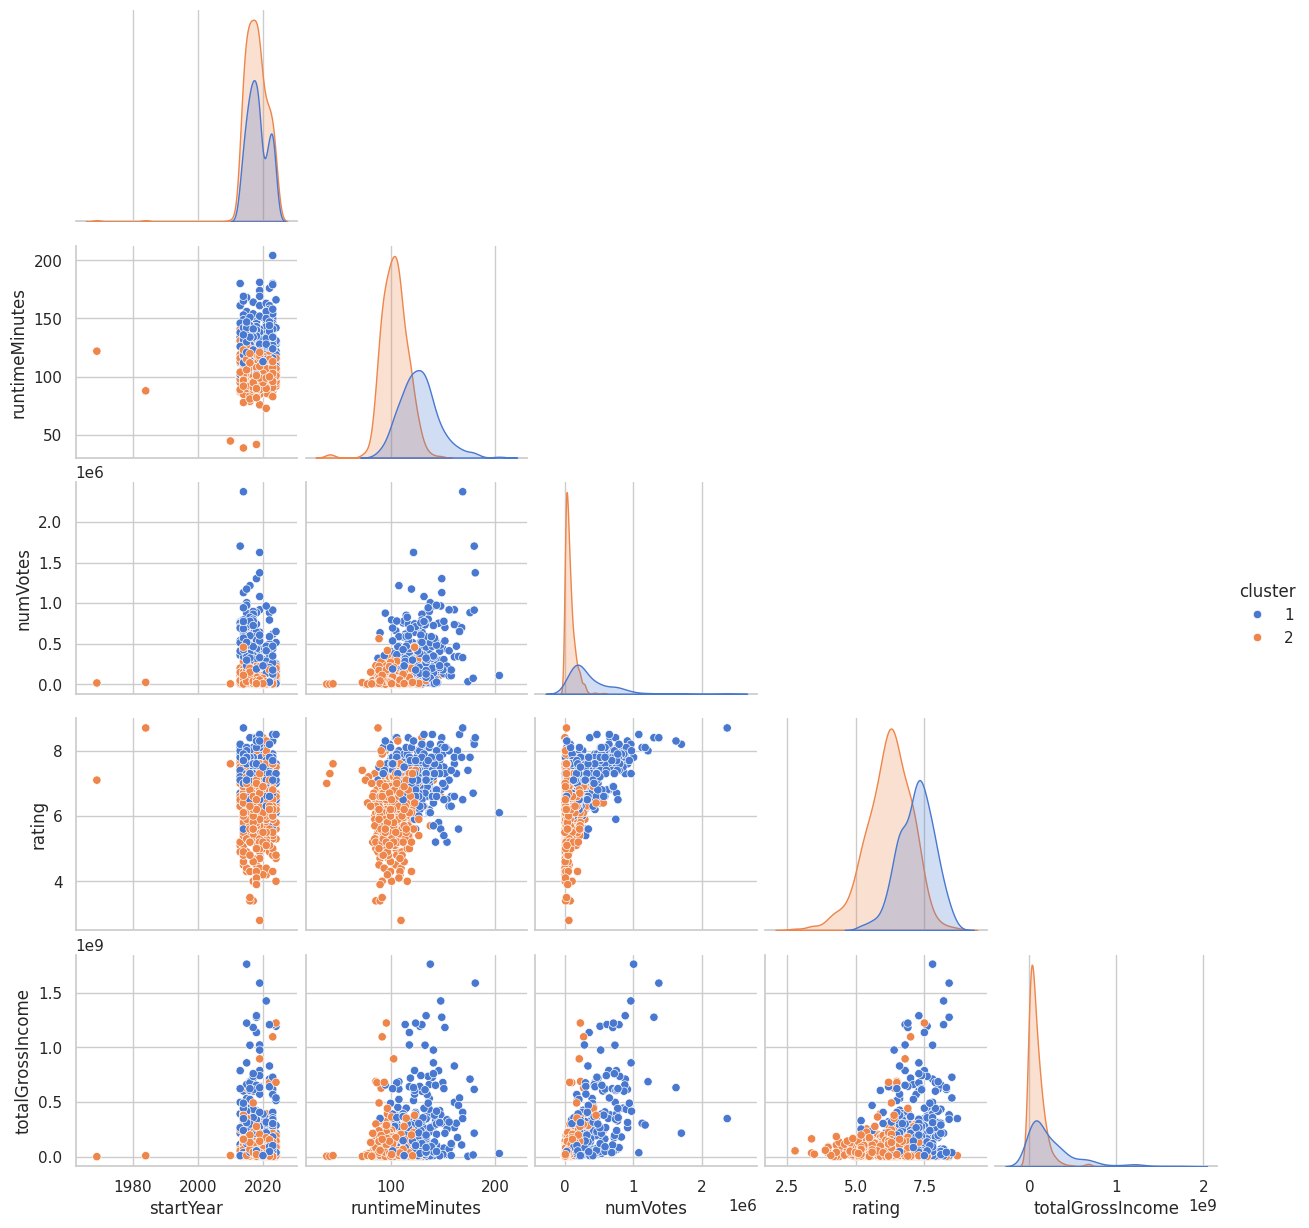

In [39]:
sns.pairplot(train, vars=['startYear', 'runtimeMinutes', 'numVotes', 'rating', 'totalGrossIncome'], hue='cluster', corner=True)

Titles from cluster 1 have on average longer runtimes, higher rating and a higher number of votes. We observe also higher variance for total gross income and num votes in cluster 1, which is to be expected, since it has smaller support.

In [40]:
train['action'] = train['genre'].apply(lambda x: 'Action' in x)
train.groupby('cluster')['action'].value_counts()

/tmp/ipykernel_28468/2635822581.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('cluster')['action'].value_counts()


cluster  action
1        False     179
         True      146
2        False     401
         True      124
Name: count, dtype: int64

Looks like action movies are overrespresented in cluster 1.

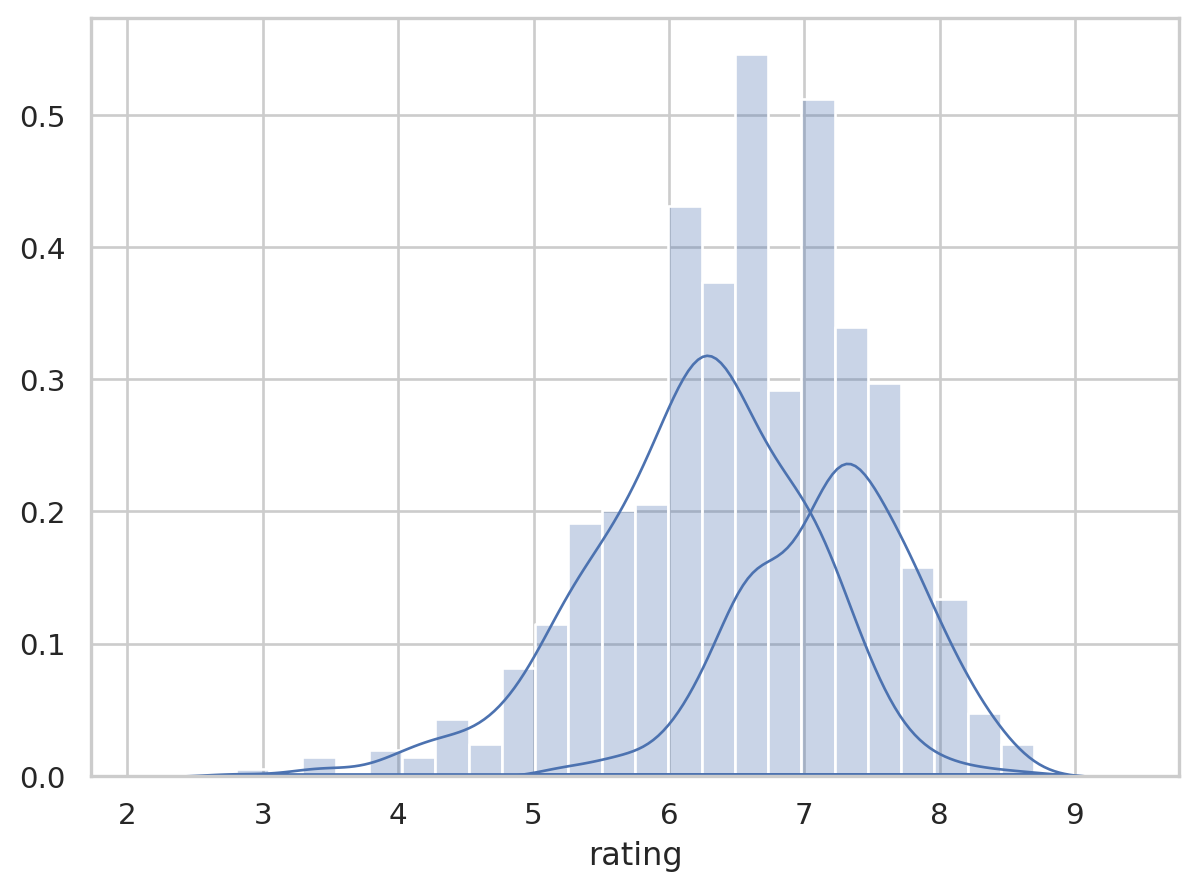

In [41]:
(
    so.Plot(train, x='rating')
    .add(so.Bars(alpha=.3), so.Hist('density'))
    .add(so.Area(fill=False), so.KDE(), group='cluster')
)

Clusters also explain the bimodal distribution of rating.

## Visualization of time series

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [43]:
ts_norm = pd.DataFrame(scaler.fit_transform(train.iloc[:,10:-4].transpose()).transpose(), index=train.index)

In [44]:
train_stacked = ts_norm.stack().reset_index()
train_stacked.columns = ('id','timestamp', 'value')
train_stacked

,id,timestamp,value
0,tt10855768,0,3.612738
1,tt10855768,1,3.779994
2,tt10855768,2,3.929865
3,tt10855768,3,2.749068
4,tt10855768,4,1.809727
...,...,...,...
84145,tt9620292,94,-1.140761
84146,tt9620292,95,-1.158493
84147,tt9620292,96,-1.143856
84148,tt9620292,97,-1.127402


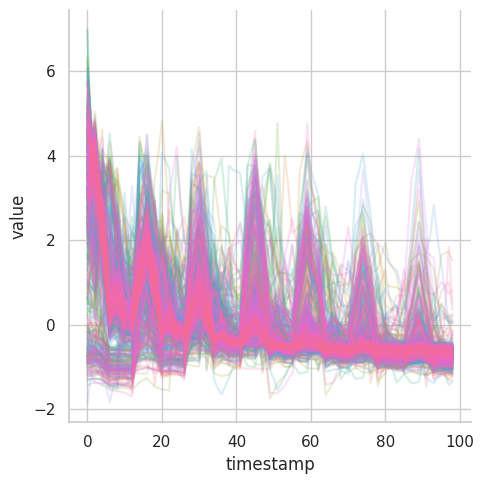

In [45]:
sns.relplot(train_stacked, x='timestamp', y='value', kind='line',hue='id', legend=False, alpha=.2)

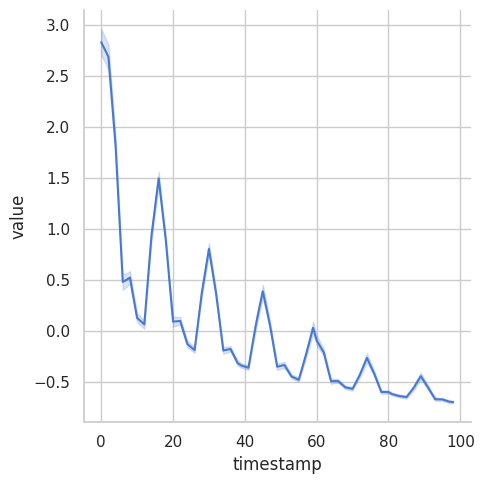

In [46]:
sns.relplot(train_stacked, x='timestamp', y='value', kind='line', legend=False)

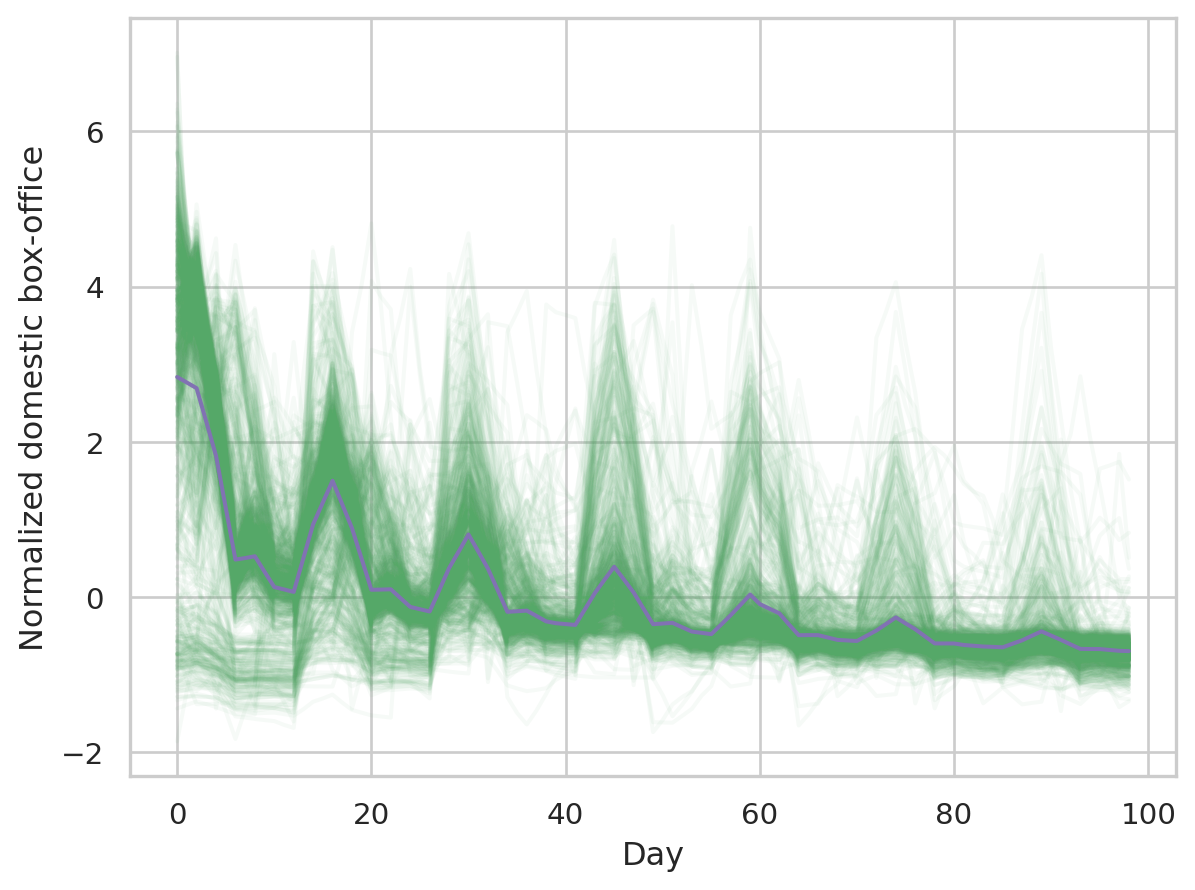

In [47]:
(
    so.Plot(train_stacked, x='timestamp', y='value')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Day', y='Normalized domestic box-office')
)

We can see that our time series show some seasonality with a cycle around two weeks. It is possible that this is determined, among other things by the day of the week.

It also looks like, while most movies have profits well over the mean in the first several day after release, some others got a slow start at the box office. We identified 145 movies that performed below average on the first day of box-office. This is a very coarse distinction: for example, among these slow-start movies we identified also __Interstellar__, which for some reason was released in the US on a Wednesday and really exploded only 2 days later but doesn't display a trend similar to that of most movies with a slow start.

In [48]:
idx = train_stacked[(train_stacked['value'] < 0) & (train_stacked['timestamp'] == 0)]['id']
train.loc[idx, 'slow'] = True
train['slow'] = train['slow'].fillna(False)
train[train['slow']].sort_values('numVotes', ascending=False)

/tmp/ipykernel_28468/4263513437.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['slow'] = train['slow'].fillna(False)


,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,rating,genre,rating_category,totalGrossIncome,...,94,95,96,97,98,99,foreign,cluster,action,slow
id,,,,,,,,,,,,,,,,,,,,,
tt0816692,Interstellar,2014,169,2374947,"[US, GB, CA]",True,8.7,"[Adventure, Drama, Sci-Fi]",High,348751709.0,...,991763.0,910905.0,786939.0,660732.0,710859.0,763250.0,False,1,False,True
tt6751668,Parasite,2019,132,1081584,[KR],True,8.5,"[Drama, Thriller]",High,35693807.0,...,186549.0,200178.0,205329.0,210187.0,199049.0,182349.0,True,1,False,True
tt1663202,The Revenant,2015,156,917349,"[US, HK, TW, AR]",True,8.0,"[Action, Adventure, Drama]",High,313004336.0,...,756110.0,818353.0,736134.0,633391.0,605567.0,577163.0,False,1,True,True
tt2024544,12 Years a Slave,2013,134,768847,"[GB, US]",True,8.1,"[Biography, Drama, History]",High,69357605.0,...,179126.0,201277.0,188885.0,176761.0,178445.0,180084.0,False,1,False,True
tt3783958,La La Land,2016,128,726547,"[US, HK]",True,8.0,"[Comedy, Drama, Music]",High,194865361.0,...,1015832.0,1445560.0,1376909.0,1256071.0,1264277.0,1270339.0,False,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt4935462,Amazing Grace,2018,89,5344,[US],True,7.5,"[Documentary, Music]",High,7251100.0,...,45707.0,47580.0,44093.0,40443.0,38710.0,37208.0,False,2,False,True
tt8884430,Echo in the Canyon,2018,82,4202,[US],True,7.0,"[Documentary, Music]",Medium High,4359367.0,...,35868.0,36497.0,36734.0,37083.0,36792.0,36465.0,False,2,False,True
tt6964076,Pavarotti,2019,114,4021,"[US, GB, FR, IT]",True,7.5,"[Documentary, Biography, Music]",High,8433752.0,...,33596.0,37989.0,37108.0,36337.0,34264.0,32315.0,False,2,False,True


For the most part these are **not** action movies.

In [49]:
pd.crosstab(train['action'], train['slow'], normalize='columns')

slow,False,True
action,,
False,0.631206,0.931034
True,0.368794,0.068966


In [50]:
train_stacked['slow'] = train_stacked['id'].isin(idx)
train_stacked['action'] = train_stacked['id'].isin(train[train['action']].index)
train_stacked['foreign'] = train_stacked['id'].isin(train[train['foreign']].index)
train_stacked['rating'] = train_stacked['id'].map(train['rating_category'].to_dict())
train_stacked['cluster'] = train_stacked['id'].map(train['cluster'].to_dict())
train_stacked['title'] = train_stacked['id'].map(train['title'].to_dict())
train_stacked


,id,timestamp,value,slow,action,foreign,rating,cluster,title
0,tt10855768,0,3.612738,False,False,False,High,2,Missing
1,tt10855768,1,3.779994,False,False,False,High,2,Missing
2,tt10855768,2,3.929865,False,False,False,High,2,Missing
3,tt10855768,3,2.749068,False,False,False,High,2,Missing
4,tt10855768,4,1.809727,False,False,False,High,2,Missing
...,...,...,...,...,...,...,...,...,...
84145,tt9620292,94,-1.140761,False,False,False,High,1,Promising Young Woman
84146,tt9620292,95,-1.158493,False,False,False,High,1,Promising Young Woman
84147,tt9620292,96,-1.143856,False,False,False,High,1,Promising Young Woman
84148,tt9620292,97,-1.127402,False,False,False,High,1,Promising Young Woman


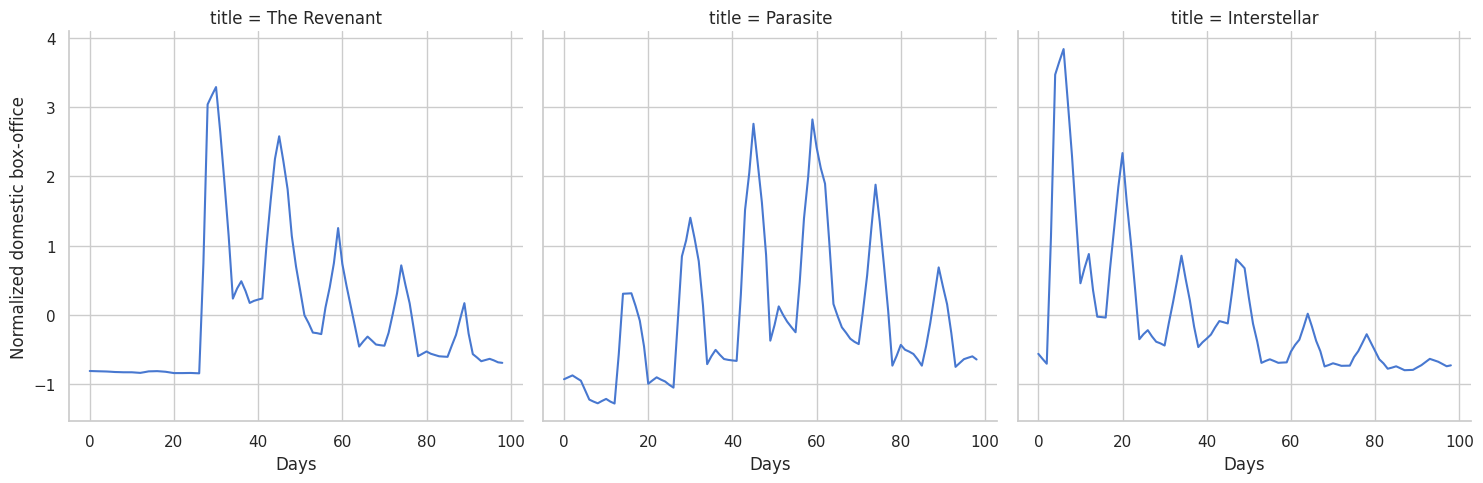

In [51]:
top_slow = list(train[train['slow']].sort_values('numVotes', ascending=False).head(3)['title'])
g = sns.relplot(train_stacked[train_stacked['title'].isin(top_slow)], x='timestamp', y='value', kind='line',col='title')
g.set_axis_labels('Days', 'Normalized domestic box-office')
plt.show()

The top 3 (for number of votes) movies that performed below average in the first day of box-office. While *Parasite* is showing the common trend among slow starters (see below), both *Interstellar* and *The Revenant* show a very different trend, more similar to that instantly remunerative movies, with a more or less offset start (for *The Revenant* it looks like data is available from the limited release of the movie).

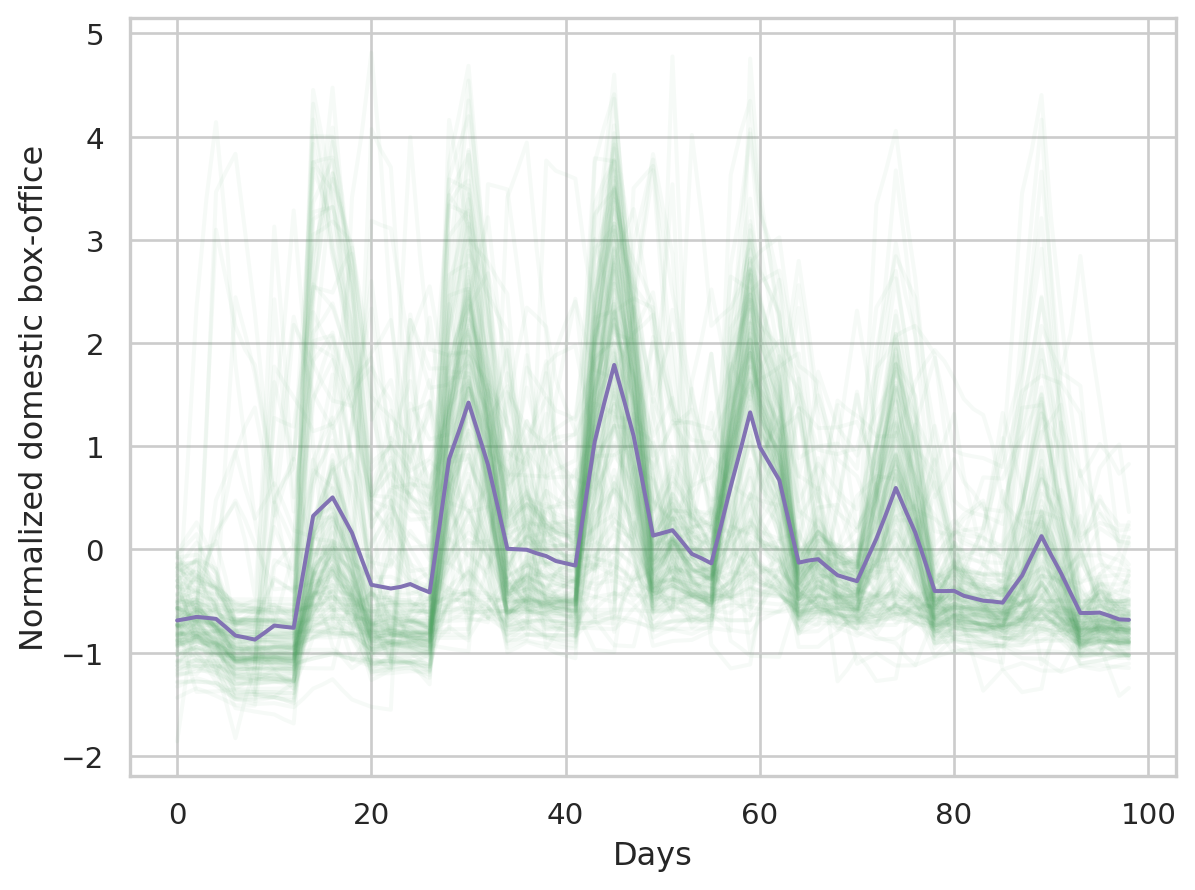

In [52]:
(
    so.Plot(train_stacked[train_stacked['slow']], x='timestamp', y='value')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office')
)

Movies that are not instant hits seem to peak, on average, around 6 weeks in.

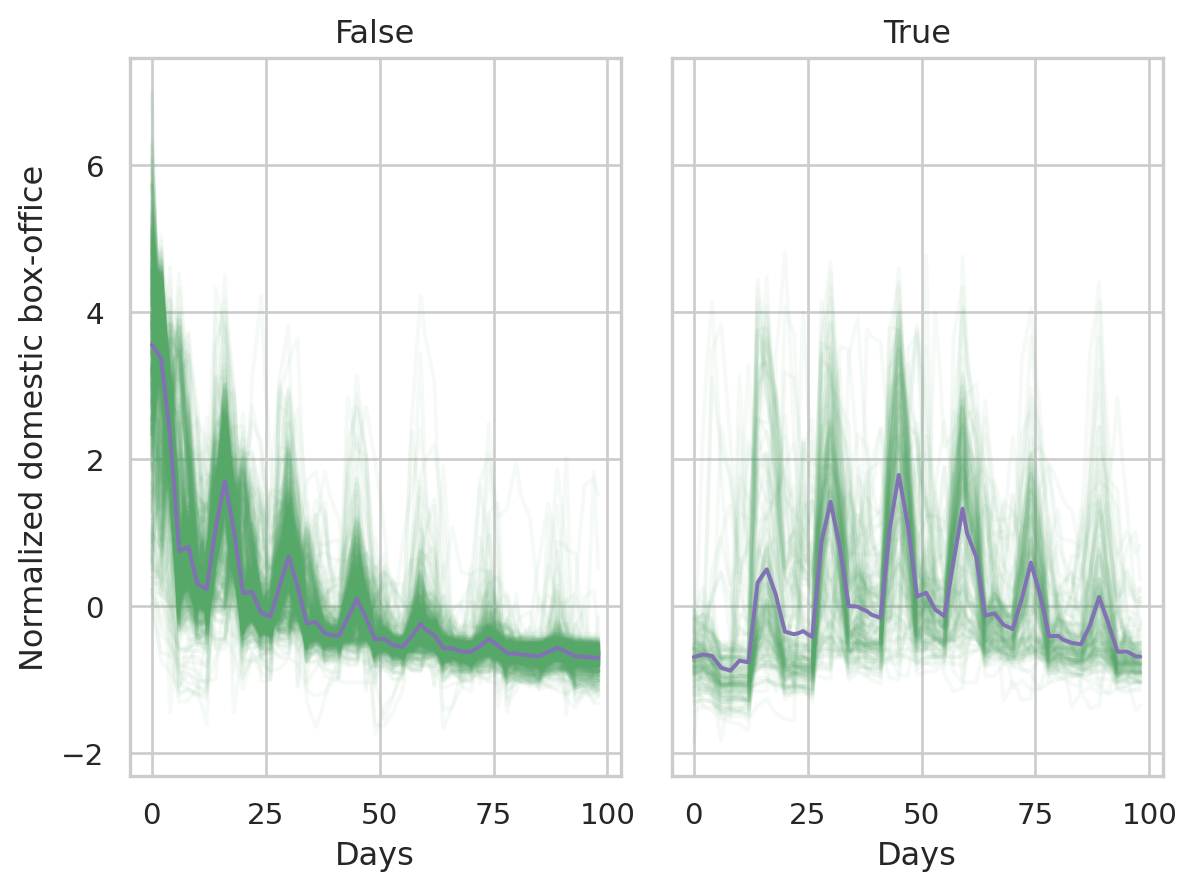

In [53]:
(
    so.Plot(train_stacked, x='timestamp', y='value')
    .facet(col='slow')
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office')
)

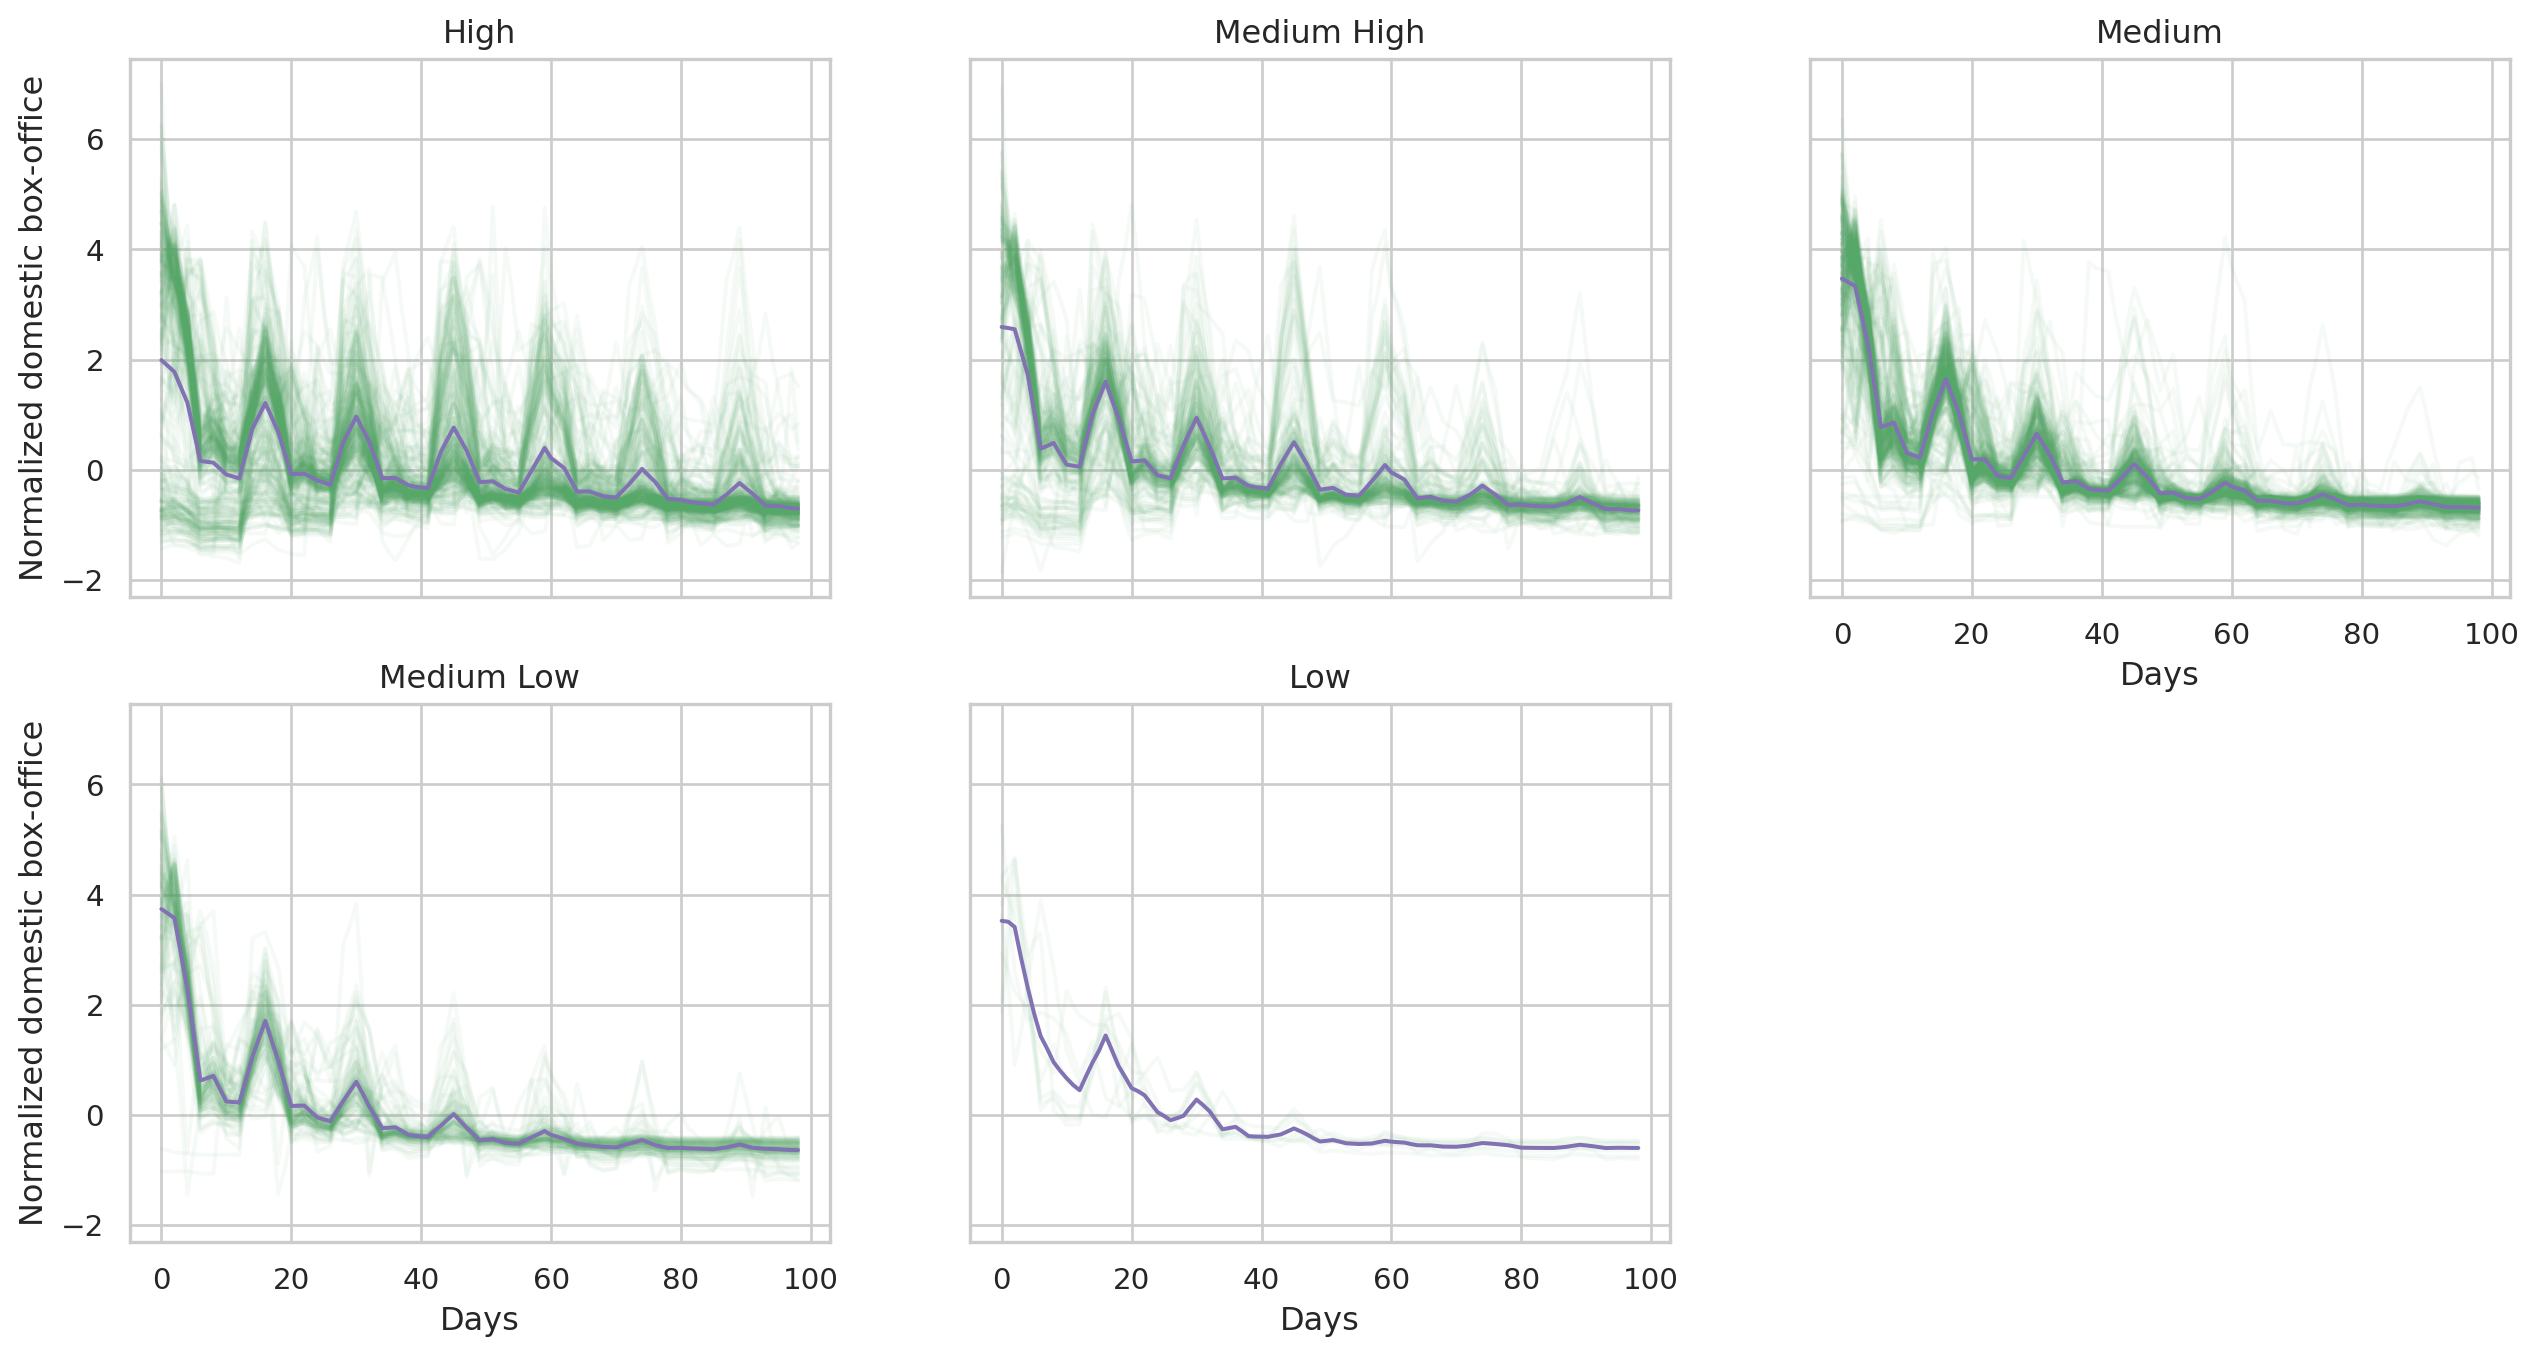

In [54]:
f = plt.Figure(figsize=(16, 8))
(
    so.Plot(train_stacked, x='timestamp', y='value')
    .facet(col='rating', wrap=3)
    .add(so.Lines(alpha=.05, color='C2'), group='id')
    .add(so.Line(color='C4'), so.Agg(func='mean'))
    .label(x='Days', y='Normalized domestic box-office')
    .on(f)
)

## Save train and test

In [55]:
train[test.columns].to_csv(results_dir / 'train_ts.csv')
test.to_csv(results_dir / 'test_ts.csv')